# iris_regression

## Imports

In [1]:
import pandas as pd

## Dataset loading and preparation

In [2]:
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
transform_map = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
df_transformed = df.copy()
df_transformed['Species'] = df['Species'].map(transform_map)
df_transformed.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


## Regression

In [4]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()

### Train-Test split

In [5]:
from sklearn.model_selection import StratifiedShuffleSplit

X = df_transformed.drop('Species', axis=1)
y = df_transformed['Species']

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=47)
split = sss.split(X, y)
for train_index, test_index in split:
    train_index = train_index
    test_index = test_index

X_train = X.iloc[train_index]
y_train = y.iloc[train_index]

X_test = X.iloc[test_index]
y_test = y.iloc[test_index]

### Fit and predict

In [6]:
lin_reg.fit(X_train, y_train)
train_predictions = lin_reg.predict(X_test)

### Transformation function

In [7]:
def back_transform(number):
    if number <= 0.6999:
        return 0
    elif number <= 1.3999:
        return 1
    else:
        return 2

### Calculating accuracy

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score 
train_predictions = pd.Series(train_predictions)
predictions_corrected = train_predictions.map(back_transform)
accuracy = accuracy_score(y_test, predictions_corrected)
recall = recall_score(y_test, predictions_corrected, labels=[0, 1, 2], average=None)
precision = precision_score(y_test, predictions_corrected, labels=[0, 1, 2], average=None)

print(f'Acuracia do modelo: {accuracy}')
print(f'Recall do modelo: {recall}')
print(f'Precisao do modelo: {precision}')

Acuracia do modelo: 0.9666666666666667
Recall do modelo: [1.  0.9 1. ]
Precisao do modelo: [1.         1.         0.90909091]


### Graph for correct and incorrect classifications

#### Checking hits

In [9]:
X_all = df_transformed.drop('Species', axis=1) 
all_predictions = pd.Series(lin_reg.predict(X_all))
df_transformed['Predictions'] = all_predictions.map(back_transform)
int_to_species = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2:'Iris-virginica'}
df_transformed['Predictions'] = df_transformed['Predictions'].map(int_to_species)
df_transformed['Species'] = df_transformed['Species'].map(int_to_species)
df_transformed['Correct Label'] = df_transformed['Species'] == df_transformed['Predictions']
df_transformed.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Predictions,Correct Label
0,1,5.1,3.5,1.4,0.2,Iris-setosa,Iris-setosa,True
1,2,4.9,3.0,1.4,0.2,Iris-setosa,Iris-setosa,True
2,3,4.7,3.2,1.3,0.2,Iris-setosa,Iris-setosa,True
3,4,4.6,3.1,1.5,0.2,Iris-setosa,Iris-setosa,True
4,5,5.0,3.6,1.4,0.2,Iris-setosa,Iris-setosa,True


#### Creating graph

[]

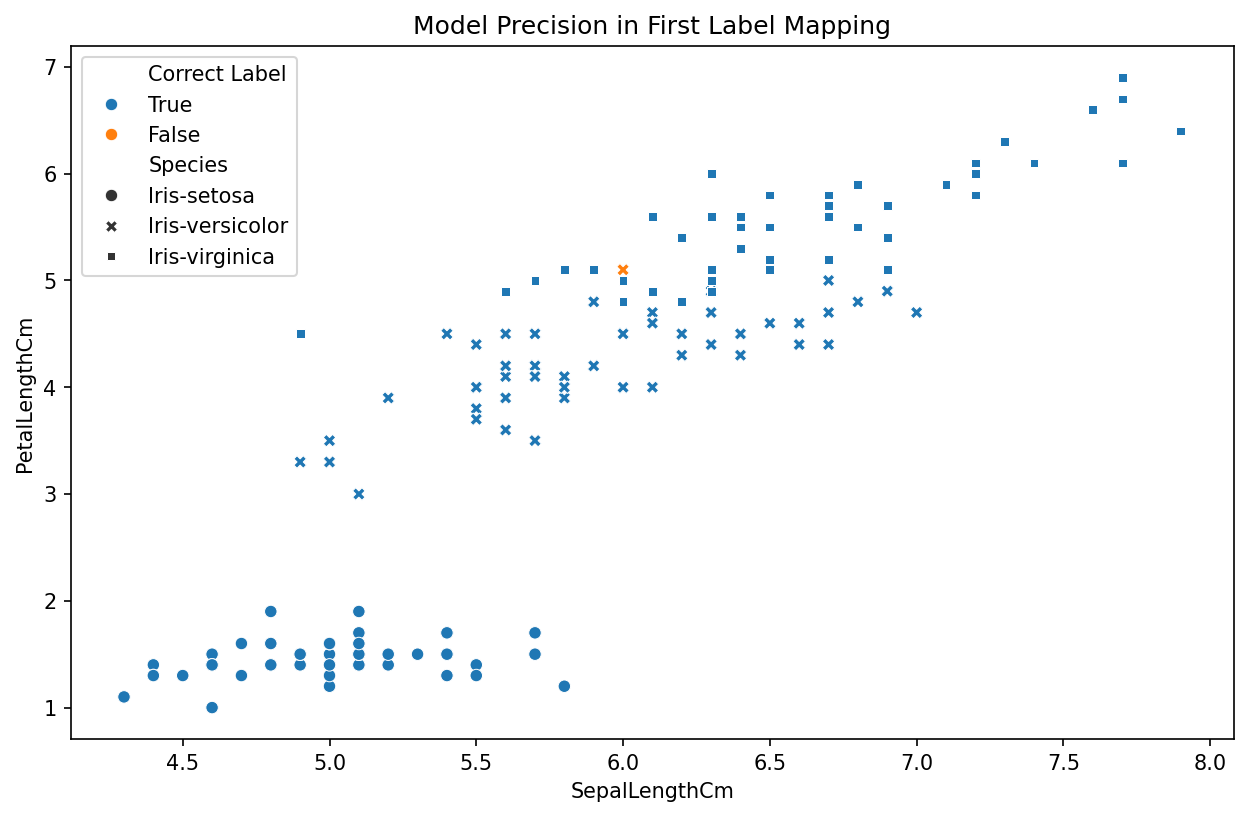

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = sns.scatterplot(df_transformed, x='SepalLengthCm', y='PetalLengthCm',
                       style='Species', hue='Correct Label', hue_order=[True, False])
fig.set_title('Model Precision in First Label Mapping')
fig.plot()

## Shuffling y

In [12]:
new_transform_map = {'Iris-setosa': 1, 'Iris-versicolor': 2, 'Iris-virginica': 0}
scnd_df = df.copy()
scnd_df['Species'] = df['Species'].map(new_transform_map)

X = scnd_df.drop('Species', axis=1)
y = scnd_df['Species']

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=47)
split = sss.split(X, y)
for train_index, test_index in split:
    train_index = train_index
    test_index = test_index

X_train = X.iloc[train_index]
y_train = y.iloc[train_index]

X_test = X.iloc[test_index]
y_test = y.iloc[test_index]

lin_reg.fit(X_train, y_train)
train_predictions = lin_reg.predict(X_test)

train_predictions = pd.Series(train_predictions)
predictions_corrected = train_predictions.map(back_transform)
accuracy = accuracy_score(y_test, predictions_corrected)
recall = recall_score(y_test, predictions_corrected, labels=[1, 2, 0], average=None)
precision = precision_score(y_test, predictions_corrected, labels=[1, 2, 0], average=None)

print(f'Acuracia do modelo: {accuracy}')
print(f'Recall do modelo: {recall}')
print(f'Precisao do modelo: {precision}')

Acuracia do modelo: 0.5333333333333333
Recall do modelo: [0.6 0.3 0.7]
Precisao do modelo: [0.375 0.5   0.875]


Percebemos que ao mudar a ordem dos numeros que codificam nossas classes,
a precisao do modelo muda. Isso provavelmente acontece pela natureza dos dados,
que ao serem descritas por um modelo de regressão linear, não necessariamente seguem
uma lógica crescente, acompanhando a linha de regressão.

### Correct classification graphs

In [13]:
X_all = scnd_df.drop('Species', axis=1) 
all_predictions = pd.Series(lin_reg.predict(X_all))
scnd_df['Predictions'] = all_predictions.map(back_transform)
int_to_species = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2:'Iris-virginica'}
scnd_df['Predictions'] = scnd_df['Predictions'].map(int_to_species)
scnd_df['Species'] = scnd_df['Species'].map(int_to_species)
scnd_df['Correct Label'] = scnd_df['Species'] == scnd_df['Predictions']
scnd_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Predictions,Correct Label
0,1,5.1,3.5,1.4,0.2,Iris-versicolor,Iris-virginica,False
1,2,4.9,3.0,1.4,0.2,Iris-versicolor,Iris-virginica,False
2,3,4.7,3.2,1.3,0.2,Iris-versicolor,Iris-virginica,False
3,4,4.6,3.1,1.5,0.2,Iris-versicolor,Iris-virginica,False
4,5,5.0,3.6,1.4,0.2,Iris-versicolor,Iris-virginica,False


#### Creating graph

[]

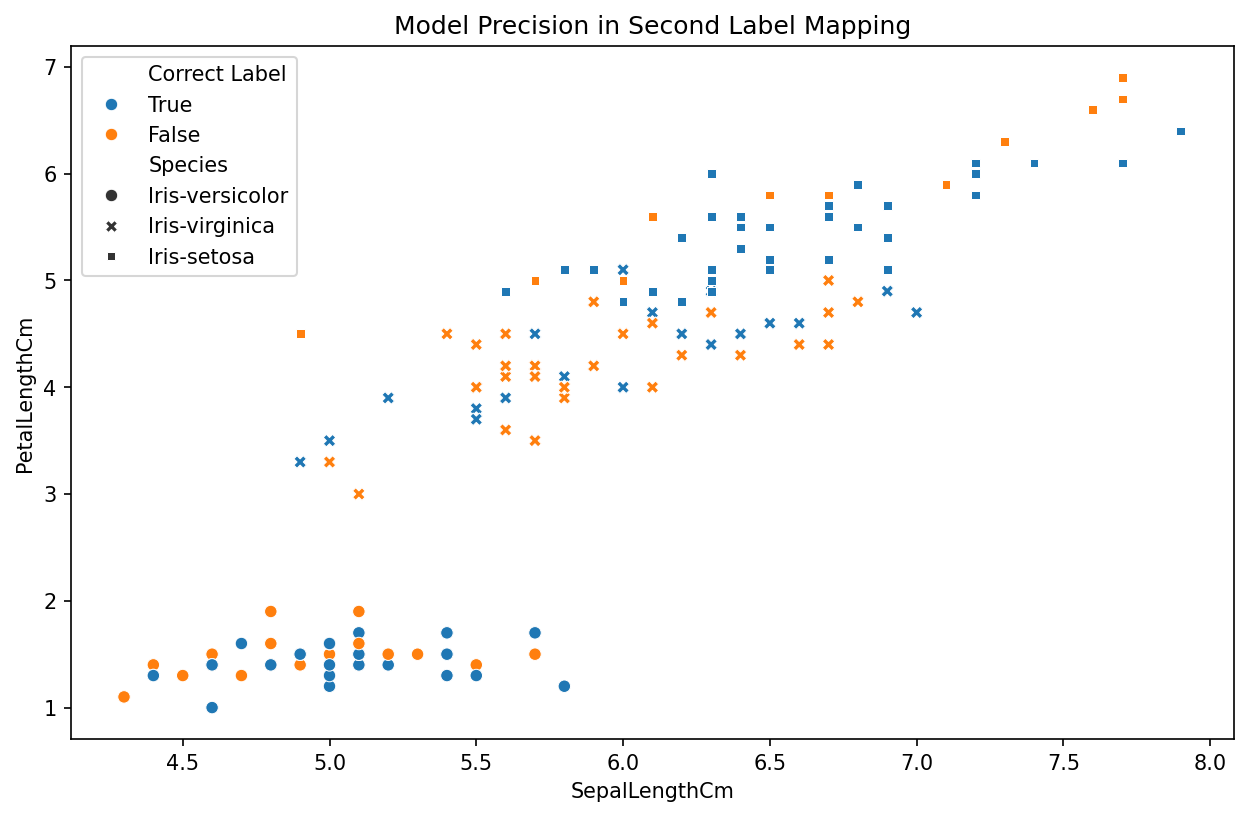

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = sns.scatterplot(scnd_df, x='SepalLengthCm', y='PetalLengthCm',
                       style='Species', hue='Correct Label', hue_order=[True, False] )
fig.set_title('Model Precision in Second Label Mapping')
fig.plot()